# Churn EDA

Phase 2 notebook for class balance, missing values, numeric relationships, and plan-level churn patterns.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path('../data/raw/churn.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('data/raw/churn.csv')

churn = pd.read_csv(DATA_PATH)
churn.head()

,customer_id,tenure,monthly_spend,usage_frequency,support_tickets,plan_type,churn_label
0,266370108b5d9e206cea296c28b9a4e5223a31f2e8e149...,26,48.80,4,0,pro,0
1,5495656ace86f6d0ce3fe39e8b230ddecccb552a382607...,13,48.80,30,0,pro,1
2,7357f8f39999c69417329088ce46f6017f4080fb3cbbd1...,22,118.50,30,0,enterprise,0
3,079c2e278460670fdc8c81f7679824dc75c18ded8216ad...,4,42.85,4,0,basic,0
4,70971f180561533fb36e22a595a5b0851dce1b1f504f5d...,11,30.95,4,1,basic,1


In [2]:
print('Shape:', churn.shape)
display(churn.info())
display(churn.isna().sum())
display(churn.describe(include='all'))

Shape: (2500, 7)
<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      2500 non-null   str    
 1   tenure           2500 non-null   int64  
 2   monthly_spend    2500 non-null   float64
 3   usage_frequency  2500 non-null   int64  
 4   support_tickets  2500 non-null   int64  
 5   plan_type        2500 non-null   str    
 6   churn_label      2500 non-null   int64  
dtypes: float64(1), int64(4), str(2)
memory usage: 304.2 KB


None

customer_id        0
tenure             0
monthly_spend      0
usage_frequency    0
support_tickets    0
plan_type          0
churn_label        0
dtype: int64

,customer_id,tenure,monthly_spend,usage_frequency,support_tickets,plan_type,churn_label
count,2500,2500.000000,2500.000000,2500.000000,2500.000000,2500,2500.000000
unique,2500,NaN,NaN,NaN,NaN,3,NaN
top,266370108b5d9e206cea296c28b9a4e5223a31f2e8e149...,NaN,NaN,NaN,NaN,pro,NaN
freq,1,NaN,NaN,NaN,NaN,1164,NaN
mean,NaN,18.456000,55.893080,14.843200,0.191600,NaN,0.363200
std,NaN,10.600123,24.539099,13.571952,0.393639,NaN,0.481018
min,NaN,1.000000,25.850000,0.000000,0.000000,NaN,0.000000
25%,NaN,9.000000,35.200000,4.000000,0.000000,NaN,0.000000
50%,NaN,19.000000,51.350000,4.000000,0.000000,NaN,0.000000
75%,NaN,28.000000,70.050000,30.000000,0.000000,NaN,1.000000


,count,rate
churn_label,,
0,1592,0.6368
1,908,0.3632


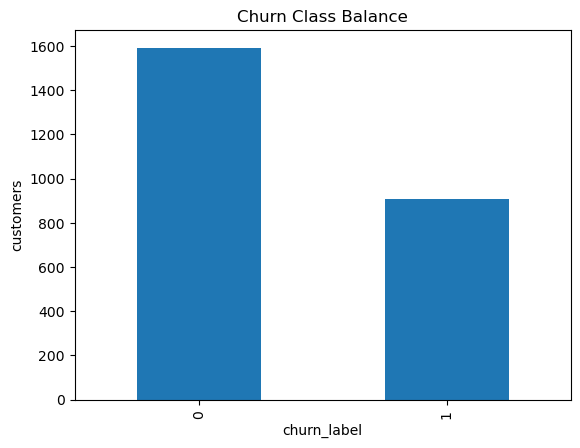

In [3]:
class_counts = churn['churn_label'].value_counts().sort_index()
class_rates = churn['churn_label'].value_counts(normalize=True).sort_index()
display(pd.DataFrame({'count': class_counts, 'rate': class_rates}))
class_counts.plot(kind='bar', title='Churn Class Balance')
plt.xlabel('churn_label')
plt.ylabel('customers')
plt.show()

In [4]:
numeric_cols = ['tenure', 'monthly_spend', 'usage_frequency', 'support_tickets']
corr = churn[numeric_cols + ['churn_label']].corr(numeric_only=True)['churn_label'].drop('churn_label')
display(corr.sort_values(key=lambda values: values.abs(), ascending=False))
display(churn.groupby('churn_label')[numeric_cols].mean().round(2))

monthly_spend     -0.498864
usage_frequency   -0.447068
support_tickets    0.329743
tenure            -0.025431
Name: churn_label, dtype: float64

,tenure,monthly_spend,usage_frequency,support_tickets
churn_label,,,,
0,18.66,65.14,19.42,0.09
1,18.10,39.69,6.81,0.36


churn_label,0,1
plan_type,,
basic,0.351,0.649
enterprise,0.934,0.066
pro,0.845,0.155


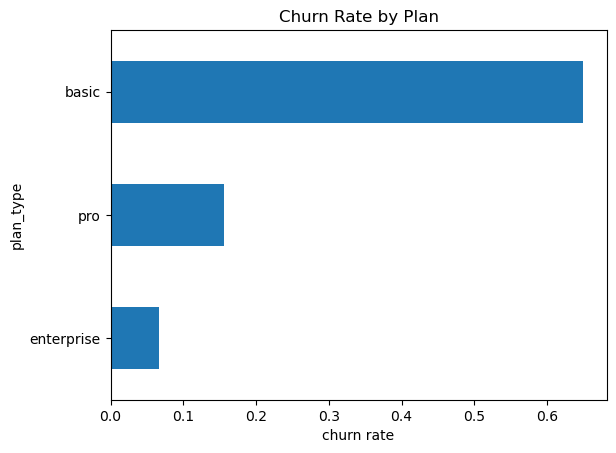

In [5]:
plan_churn = pd.crosstab(churn['plan_type'], churn['churn_label'], normalize='index')
display(plan_churn.round(3))
plan_churn[1].sort_values().plot(kind='barh', title='Churn Rate by Plan')
plt.xlabel('churn rate')
plt.ylabel('plan_type')
plt.show()

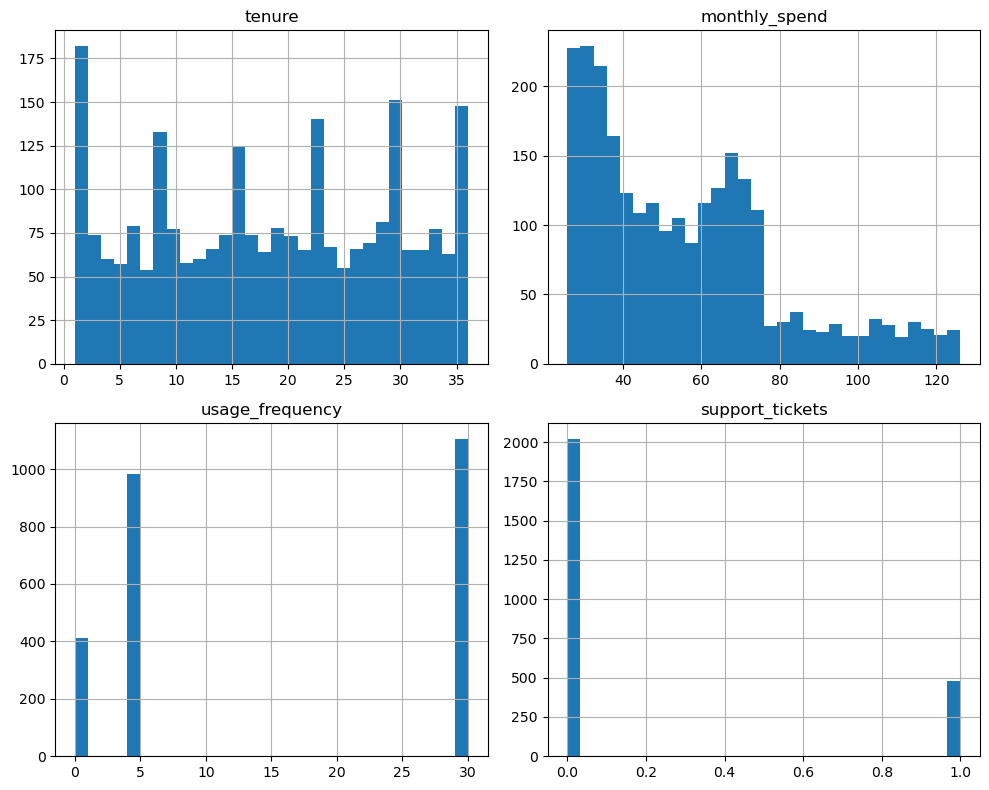

In [6]:
churn[numeric_cols].hist(figsize=(10, 8), bins=30)
plt.tight_layout()
plt.show()